# Multi-Kernel Attention 1D CNN — Subject-Dependent Within-Subject, Strict Leakage-Safe EMG + ACC

**NinaPro DB7 | S01–S22 | gestures 13–29 | one separately trained CNN per subject | EMG + ACC**

This is a **subject-dependent / subject-specific within-subject** evaluation. For each subject and gesture, the six complete repetitions are assigned first as **4 train, 1 validation, 1 test**. A completely separate CNN is trained for each subject. EMG filtering and ACC resampling are performed independently inside each already-assigned repetition, followed by boundary trimming and overlapping window creation.

**Disk-safe change:** raw signals and overlapping windows are processed for only one subject at a time and are **not written to persistent `.npz` caches**. After that subject is evaluated, large arrays and temporary model checkpoints are released before moving to the next subject.


In [1]:
import os, gc, time, json, warnings, random, re, shutil
from pathlib import Path
from copy import deepcopy
from math import gcd

import numpy as np
import pandas as pd
from scipy import io
from scipy.signal import (
    resample_poly, butter, sosfiltfilt, iirnotch, filtfilt
)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve,
)

try:
    from thop import profile as thop_profile
    HAS_THOP = True
except ImportError:
    HAS_THOP = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Configuration — matched to the leakage-safe DNN/GNN within-subject protocol


In [2]:
def _find_kaggle_input() -> Path:
    base = Path('/kaggle/input')
    if not base.exists():
        return Path('/kaggle/input/ninapro-db7/Dataset')

    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir()
        )

    def _search(root, depth=0):
        if depth > 5:
            return None
        if _has_subjects(root):
            return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    result = _search(child, depth + 1)
                    if result is not None:
                        return result
        except PermissionError:
            pass
        return None

    result = _search(base)
    return result if result else Path('/kaggle/input/ninapro-db7/Dataset')


class Config:
    KAGGLE_INPUT = _find_kaggle_input()
    KAGGLE_WORKING = (
        Path('/kaggle/working')
        if Path('/kaggle').exists()
        else Path.cwd() / 'mka_cnn_within_working'
    )

    RUN_TAG = 'v5_mka_cnn_subject_dependent_r4v1t1_emg_acc_disk_safe'
    CKPT_DIR = KAGGLE_WORKING / f'ckpts_{RUN_TAG}'
    PLOT_DIR = KAGGLE_WORKING / f'plots_{RUN_TAG}'
    RESULTS_DIR = KAGGLE_WORKING / f'results_{RUN_TAG}'

    # Population
    INTACT_SUBJECTS = list(range(1, 21))
    AMPUTEE_SUBJECTS = [21, 22]
    SUBJECTS = list(range(1, 23))
    RUN_SUBJECTS = SUBJECTS.copy()  # use [1, 2] for a quick Kaggle smoke test
    PLOT_EACH_SUBJECT = False

    # True within-subject repetition split
    REPS_PER_GESTURE = 6
    TRAIN_REPS = 4
    VAL_REPS = 1
    TEST_REPS = 1

    # Labels 13..29 span E1 and E2
    EXERCISE_IDS = (1, 2)
    GESTURE_MIN = 13
    GESTURE_MAX = 29
    N_CLASSES = GESTURE_MAX - GESTURE_MIN + 1

    # Signal
    EMG_FS = 2000
    ACC_FS = 148
    TARGET_FS = 2000
    EMG_KEY = 'emg'
    ACC_KEY = 'acc'
    LBL_KEY = 'restimulus'
    N_EMG_CH = 12

    # EMG + ACC multimodal experiment.
    # ACC is segmented and resampled independently inside each complete repetition.
    USE_ACC = True

    # Fixed signal preprocessing; no statistics are learned from test data.
    BANDPASS_LOW_HZ = 20.0
    BANDPASS_HIGH_HZ = 450.0
    FILTER_ORDER = 4
    NOTCH_HZ = 50.0
    NOTCH_Q = 30.0

    # Same windowing as corrected DNN/GNN
    WIN_MS = 400
    STEP_MS = 100
    TRIM_MS = 100
    WIN_SAMPLES = int(WIN_MS * TARGET_FS / 1000)
    STEP_SAMPLES = int(STEP_MS * TARGET_FS / 1000)
    TRIM_SAMPLES = int(TRIM_MS * TARGET_FS / 1000)

    # CNN
    DROPOUT = 0.15

    # Optimization
    MIN_EPOCHS = 20
    MAX_EPOCHS = 150
    PATIENCE = 15
    MIN_REFIT_EPOCHS = 10
    BATCH_SIZE = 128
    LR = 3e-4
    WEIGHT_DECAY = 1e-4
    GRAD_CLIP = 5.0
    NUM_WORKERS = 0  # safer for large in-memory subject arrays on Kaggle
    REFIT_ON_TRAIN_PLUS_VAL = True
    KEEP_SUBJECT_CHECKPOINTS = False
    CLEAN_LEGACY_V4_CACHES = True

    SEED = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

for directory in [
    Config.CKPT_DIR,
    Config.PLOT_DIR,
    Config.RESULTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


def _clean_known_legacy_v4_caches():
    """Delete only large caches created by the earlier v4 MKA-CNN notebook."""
    if not Config.CLEAN_LEGACY_V4_CACHES:
        return

    legacy_names = [
        'raw_continuous_cache_v4_mka_cnn_emg_acc_subject_specific_r4v1t1_strict',
        'repetition_filtered_window_cache_v4_mka_cnn_emg_acc_subject_specific_r4v1t1_strict',
    ]

    for name in legacy_names:
        path = Config.KAGGLE_WORKING / name
        if path.exists() and path.is_dir():
            shutil.rmtree(path, ignore_errors=True)
            print(f'Removed old generated cache: {path.name}')


_clean_known_legacy_v4_caches()

assert Config.TRAIN_REPS + Config.VAL_REPS + Config.TEST_REPS == Config.REPS_PER_GESTURE
assert Config.USE_ACC is True

print(f'Device             : {Config.DEVICE}')
print(f'Population         : {Config.SUBJECTS}')
print(f'Subject models     : {Config.RUN_SUBJECTS}')
print('Evaluation         : SUBJECT-DEPENDENT / SUBJECT-SPECIFIC WITHIN-SUBJECT')
print('Training rule      : train a fresh independent CNN separately for each subject')
print('Exercise files      : E1 + E2')
print(f'Input modality     : {"EMG + ACC" if Config.USE_ACC else "EMG only"}')
print('ACC handling       : repetition-local segment + repetition-local resampling')
print(f'Window / step      : {Config.WIN_MS} / {Config.STEP_MS} ms')
print(f'Boundary trim      : {Config.TRIM_MS} ms per repetition side')
print(f'Gestures           : {Config.GESTURE_MIN}–{Config.GESTURE_MAX} ({Config.N_CLASSES} classes)')
print(f'Within split       : {Config.TRAIN_REPS} train + {Config.VAL_REPS} val + {Config.TEST_REPS} test repetitions')
print(f'Refit train+val    : {Config.REFIT_ON_TRAIN_PLUS_VAL}')
print('Persistent windows : disabled (disk-safe)')
print('Persistent raw cache: disabled (disk-safe)')

Device             : cuda
Population         : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Subject models     : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Evaluation         : SUBJECT-DEPENDENT / SUBJECT-SPECIFIC WITHIN-SUBJECT
Training rule      : train a fresh independent CNN separately for each subject
Exercise files      : E1 + E2
Input modality     : EMG + ACC
ACC handling       : repetition-local segment + repetition-local resampling
Window / step      : 400 / 100 ms
Boundary trim      : 100 ms per repetition side
Gestures           : 13–29 (17 classes)
Within split       : 4 train + 1 val + 1 test repetitions
Refit train+val    : True
Persistent windows : disabled (disk-safe)
Persistent raw cache: disabled (disk-safe)


In [3]:
# Reproducibility and protocol assertions
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

assert Config.WIN_MS == 400
assert Config.STEP_MS == 100
assert Config.REPS_PER_GESTURE == 6
assert (Config.TRAIN_REPS, Config.VAL_REPS, Config.TEST_REPS) == (4, 1, 1)

print('Leakage-safe protocol configured.')

Leakage-safe protocol configured.


# Raw EMG + ACC loading — all signal transforms happen only AFTER repetition assignment


In [4]:
class RawEMGACCPreprocessor:
    """
    Load RAW EMG, RAW accelerometer and labels from one NinaPro file.

    No filtering, no ACC resampling, no label masking and no windowing happen here.
    Keeping each source file separate preserves the exact temporal mapping needed to
    extract a matching ACC interval for every EMG repetition.
    """

    @staticmethod
    def _find_key(data, candidates):
        for candidate in candidates:
            for key in data:
                if key.lower() == candidate.lower():
                    return key
        return None

    @staticmethod
    def _time_major(array, expected_channels=None, name='signal'):
        array = np.asarray(array)

        if array.ndim == 1:
            array = array[:, None]
        if array.ndim != 2:
            raise RuntimeError(
                f'{name}: expected 2-D array, got shape {array.shape}.'
            )

        if expected_channels is not None:
            if array.shape[1] == expected_channels:
                return array
            if array.shape[0] == expected_channels:
                return array.T
            raise RuntimeError(
                f'{name}: neither dimension matches expected '
                f'{expected_channels} channels: {array.shape}.'
            )

        # For ACC the time dimension should be much larger than channel count.
        if array.shape[0] < array.shape[1] and array.shape[0] <= 128:
            array = array.T

        return array

    def apply(self, mat_path: Path):
        data = io.loadmat(str(mat_path))

        emg_key = self._find_key(data, [Config.EMG_KEY])
        acc_key = self._find_key(data, [Config.ACC_KEY])
        lbl_key = self._find_key(
            data,
            [Config.LBL_KEY, 'stimulus', 'label', 'labels'],
        )

        if emg_key is None:
            raise KeyError(f'No EMG key in {mat_path.name}.')
        if acc_key is None:
            raise KeyError(
                f'No ACC key in {mat_path.name}; EMG+ACC experiment requires accelerometer data.'
            )
        if lbl_key is None:
            raise KeyError(f'No label key in {mat_path.name}.')

        emg = self._time_major(
            data[emg_key],
            expected_channels=Config.N_EMG_CH,
            name=f'{mat_path.name} EMG',
        ).astype(np.float32)

        acc = self._time_major(
            data[acc_key],
            expected_channels=None,
            name=f'{mat_path.name} ACC',
        ).astype(np.float32)

        labels = np.asarray(
            data[lbl_key]
        ).reshape(-1).astype(np.int32)

        # restimulus is aligned with the EMG time base.
        n = min(len(emg), len(labels))
        emg = emg[:n]
        labels = labels[:n]

        if len(acc) < 2:
            raise RuntimeError(
                f'{mat_path.name}: ACC has only {len(acc)} samples.'
            )

        return emg, acc, labels


class RepetitionEMGFilter:
    """Zero-phase EMG filtering applied to one already-assigned repetition only."""

    def __init__(self):
        nyquist = Config.EMG_FS / 2.0
        self.sos = butter(
            Config.FILTER_ORDER,
            [
                Config.BANDPASS_LOW_HZ / nyquist,
                Config.BANDPASS_HIGH_HZ / nyquist,
            ],
            btype='bandpass',
            output='sos',
        )
        self.b_notch, self.a_notch = iirnotch(
            Config.NOTCH_HZ / nyquist,
            Config.NOTCH_Q,
        )

    def apply(self, repetition_emg):
        repetition_emg = np.asarray(
            repetition_emg,
            dtype=np.float32,
        )

        if repetition_emg.ndim != 2:
            raise ValueError(
                f'Expected (time,channels), got {repetition_emg.shape}.'
            )
        if len(repetition_emg) < 64:
            raise RuntimeError(
                f'EMG repetition unexpectedly short: {len(repetition_emg)} samples.'
            )

        filtered = sosfiltfilt(
            self.sos,
            repetition_emg,
            axis=0,
        )
        filtered = filtfilt(
            self.b_notch,
            self.a_notch,
            filtered,
            axis=0,
        )
        return filtered.astype(np.float32)


class RepetitionACCResampler:
    """
    Map an EMG repetition interval to the corresponding interval of the RAW ACC
    recording from the SAME source file, then resample only that ACC slice.

    This is leakage-safe because resample_poly never sees ACC samples belonging
    to another train/validation/test repetition.
    """

    @staticmethod
    def extract_matching_interval(
        file_acc: np.ndarray,
        file_emg_length: int,
        emg_start: int,
        emg_end: int,
    ) -> np.ndarray:
        if not (0 <= emg_start < emg_end <= file_emg_length):
            raise ValueError(
                f'Invalid EMG interval [{emg_start}, {emg_end}) '
                f'for file length {file_emg_length}.'
            )

        ratio = len(file_acc) / float(file_emg_length)

        # ceil(start) and ceil(end) keep selected ACC timestamps inside the
        # EMG repetition's temporal interval rather than borrowing a sample
        # from the preceding repetition/rest segment.
        acc_start = int(np.ceil(emg_start * ratio))
        acc_end = int(np.ceil(emg_end * ratio))

        acc_start = max(0, min(acc_start, len(file_acc) - 1))
        acc_end = max(acc_start + 1, min(acc_end, len(file_acc)))

        acc_rep = file_acc[acc_start:acc_end].copy()
        if len(acc_rep) < 2:
            raise RuntimeError(
                f'Mapped ACC repetition is too short: {len(acc_rep)} samples.'
            )

        return acc_rep

    @staticmethod
    def resample_to_emg_length(
        acc_rep: np.ndarray,
        target_length: int,
    ) -> np.ndarray:
        source_length = len(acc_rep)
        divisor = gcd(source_length, target_length)
        up = target_length // divisor
        down = source_length // divisor

        resampled = resample_poly(
            acc_rep,
            up,
            down,
            axis=0,
        ).astype(np.float32)

        # scipy normally gives the exact target length for this reduced ratio.
        # Handle any implementation-level one-sample discrepancy without using
        # data outside this repetition.
        if len(resampled) > target_length:
            resampled = resampled[:target_length]
        elif len(resampled) < target_length:
            pad_count = target_length - len(resampled)
            pad = np.repeat(
                resampled[-1:, :],
                pad_count,
                axis=0,
            )
            resampled = np.vstack([resampled, pad])

        if len(resampled) != target_length:
            raise RuntimeError(
                f'ACC resampling length mismatch: '
                f'{len(resampled)} != {target_length}.'
            )

        return resampled.astype(np.float32)


print('Raw EMG+ACC loader, repetition-local EMG filter and ACC resampler defined.')

Raw EMG+ACC loader, repetition-local EMG filter and ACC resampler defined.


# Subject loader — split complete repetitions first, then process EMG + ACC locally


In [5]:
class SubjectLoader:
    """
    Disk-safe subject loader.

    Only ONE subject is held in memory at a time. No raw signal cache and no
    overlapping-window cache is written to /kaggle/working.
    """

    def __init__(self):
        self.preprocessor = RawEMGACCPreprocessor()
        self.rep_filter = RepetitionEMGFilter()
        self.acc_resampler = RepetitionACCResampler()

    def _find_subject_dir(self, sid: int) -> Path:
        candidates = [
            Config.KAGGLE_INPUT / f'Subject_{sid}',
            Config.KAGGLE_INPUT / f'subject_{sid}',
            Config.KAGGLE_INPUT / f'S{sid}',
            Config.KAGGLE_INPUT / f's{sid}',
        ]
        for path in candidates:
            if path.is_dir():
                return path

        for path in sorted(Config.KAGGLE_INPUT.iterdir()):
            if path.is_dir() and path.name.lower().endswith(str(sid)):
                return path

        raise FileNotFoundError(
            f'Cannot find subject {sid} under {Config.KAGGLE_INPUT}.'
        )

    @staticmethod
    def _is_exercise_file(path: Path, exercise_id: int) -> bool:
        name = path.stem.upper()
        return bool(
            re.search(rf'(^|_)E{exercise_id}(_|$)', name)
        )

    def _selected_files(self, sid: int):
        subject_dir = self._find_subject_dir(sid)
        all_mat_files = (
            sorted(subject_dir.glob('*.mat'))
            or sorted(subject_dir.rglob('*.mat'))
        )

        selected = []
        for exercise_id in Config.EXERCISE_IDS:
            matches = [
                path
                for path in all_mat_files
                if self._is_exercise_file(path, exercise_id)
            ]
            if not matches:
                raise FileNotFoundError(
                    f'S{sid:02d}: missing E{exercise_id}. '
                    f'Available: {[p.name for p in all_mat_files[:15]]}'
                )
            selected.extend(matches)

        return selected

    def _load_raw_parts_from_source(self, sid: int):
        """
        Read E1/E2 directly from the read-only Kaggle input and keep them only
        for the current subject.
        """
        parts = []
        acc_channel_counts = set()

        for index, mat_file in enumerate(self._selected_files(sid)):
            emg, acc, labels = self.preprocessor.apply(mat_file)

            if emg.shape[1] != Config.N_EMG_CH:
                raise RuntimeError(
                    f'S{sid:02d}, {mat_file.name}: expected '
                    f'{Config.N_EMG_CH} EMG channels, got {emg.shape[1]}.'
                )

            if acc.shape[1] <= 0:
                raise RuntimeError(
                    f'S{sid:02d}, {mat_file.name}: ACC is required.'
                )

            acc_channel_counts.add(int(acc.shape[1]))

            parts.append({
                'file_index': int(index),
                'file_name': mat_file.name,
                'emg': emg.astype(np.float32, copy=False),
                'acc': acc.astype(np.float32, copy=False),
                'labels': labels.astype(np.int32, copy=False),
            })

        if len(acc_channel_counts) != 1:
            raise RuntimeError(
                f'S{sid:02d}: inconsistent ACC channel counts across E1/E2: '
                f'{sorted(acc_channel_counts)}.'
            )

        return parts, int(next(iter(acc_channel_counts)))

    @staticmethod
    def _constant_label_runs(labels: np.ndarray):
        if len(labels) == 0:
            return

        boundaries = np.flatnonzero(
            np.diff(labels) != 0
        ) + 1
        starts = np.r_[0, boundaries]
        ends = np.r_[boundaries, len(labels)]

        for start, end in zip(starts, ends):
            yield (
                int(start),
                int(end),
                int(labels[start]),
            )

    @staticmethod
    def _repetition_id(sid, gesture, repetition_index):
        return (
            int(sid),
            int(gesture),
            int(repetition_index + 1),
        )

    @staticmethod
    def _split_repetition_indices(sid, gesture):
        rng = np.random.default_rng(
            Config.SEED
            + 1009 * int(sid)
            + 9176 * int(gesture)
        )
        perm = rng.permutation(
            Config.REPS_PER_GESTURE
        ).tolist()

        test_idx = sorted(
            perm[:Config.TEST_REPS]
        )
        val_idx = sorted(
            perm[
                Config.TEST_REPS:
                Config.TEST_REPS + Config.VAL_REPS
            ]
        )
        train_idx = sorted(
            perm[
                Config.TEST_REPS
                + Config.VAL_REPS:
            ]
        )

        if (
            len(train_idx) != Config.TRAIN_REPS
            or len(val_idx) != Config.VAL_REPS
            or len(test_idx) != Config.TEST_REPS
        ):
            raise RuntimeError('Unexpected repetition split size.')

        return train_idx, val_idx, test_idx

    def _collect_repetitions(self, parts):
        runs_by_gesture = {
            gesture: []
            for gesture in range(
                Config.GESTURE_MIN,
                Config.GESTURE_MAX + 1,
            )
        }

        for part_index, part in enumerate(parts):
            for (
                run_start,
                run_end,
                gesture,
            ) in self._constant_label_runs(part['labels']):
                if gesture in runs_by_gesture:
                    runs_by_gesture[gesture].append({
                        'part_index': int(part_index),
                        'start': int(run_start),
                        'end': int(run_end),
                    })

        return runs_by_gesture

    def build_subject_splits(
        self,
        sid: int,
        expected_n_acc_ch=None,
    ):
        """
        SUBJECT-DEPENDENT / WITHIN-SUBJECT leakage-safe ordering:

        one subject's raw E1/E2
          -> identify complete repetitions
          -> 4 train / 1 val / 1 test per gesture
          -> prove repetition IDs are disjoint
          -> filter each already-assigned EMG repetition locally
          -> extract and resample matching ACC interval locally
          -> concatenate EMG+ACC
          -> trim repetition boundaries
          -> create windows inside that repetition only

        Returned arrays live in RAM only and are deleted after this subject is
        trained/evaluated.
        """
        parts, n_acc_ch = self._load_raw_parts_from_source(sid)

        if (
            expected_n_acc_ch is not None
            and int(n_acc_ch) != int(expected_n_acc_ch)
        ):
            raise RuntimeError(
                f'S{sid:02d}: ACC channels={n_acc_ch}, '
                f'expected={expected_n_acc_ch}.'
            )

        runs_by_gesture = self._collect_repetitions(parts)

        split_X = {'train': [], 'val': [], 'test': []}
        split_y = {'train': [], 'val': [], 'test': []}
        split_rep_ids = {
            'train': set(),
            'val': set(),
            'test': set(),
        }
        assignment = {}

        expected_channels = Config.N_EMG_CH + n_acc_ch

        for gesture, runs in runs_by_gesture.items():
            if len(runs) != Config.REPS_PER_GESTURE:
                diagnostic = [
                    (
                        parts[record['part_index']]['file_name'],
                        record['start'],
                        record['end'],
                    )
                    for record in runs
                ]
                raise RuntimeError(
                    f'S{sid:02d}, gesture {gesture}: expected exactly '
                    f'{Config.REPS_PER_GESTURE} repetitions, found {len(runs)}. '
                    f'Runs={diagnostic}'
                )

            train_idx, val_idx, test_idx = (
                self._split_repetition_indices(
                    sid,
                    gesture,
                )
            )

            assignment[str(gesture)] = {
                'train_reps': [int(i + 1) for i in train_idx],
                'val_reps': [int(i + 1) for i in val_idx],
                'test_reps': [int(i + 1) for i in test_idx],
            }

            split_indices = {
                'train': train_idx,
                'val': val_idx,
                'test': test_idx,
            }
            class_id = gesture - Config.GESTURE_MIN

            # Register identities BEFORE filtering, resampling, or windowing.
            for split_name, rep_indices in split_indices.items():
                for rep_index in rep_indices:
                    split_rep_ids[split_name].add(
                        self._repetition_id(
                            sid,
                            gesture,
                            rep_index,
                        )
                    )

            assert split_rep_ids['train'].isdisjoint(
                split_rep_ids['val']
            )
            assert split_rep_ids['train'].isdisjoint(
                split_rep_ids['test']
            )
            assert split_rep_ids['val'].isdisjoint(
                split_rep_ids['test']
            )

            for split_name, rep_indices in split_indices.items():
                for rep_index in rep_indices:
                    record = runs[rep_index]
                    part = parts[record['part_index']]

                    run_start = record['start']
                    run_end = record['end']

                    # RAW EMG repetition.
                    emg_raw = part['emg'][
                        run_start:run_end
                    ].copy()

                    # Matching RAW ACC interval from the SAME source file.
                    acc_raw = (
                        self.acc_resampler.extract_matching_interval(
                            file_acc=part['acc'],
                            file_emg_length=len(part['emg']),
                            emg_start=run_start,
                            emg_end=run_end,
                        )
                    )

                    # Both operations see ONLY this already-assigned repetition.
                    emg_filtered = self.rep_filter.apply(
                        emg_raw
                    )
                    acc_resampled = (
                        self.acc_resampler.resample_to_emg_length(
                            acc_raw,
                            target_length=len(emg_filtered),
                        )
                    )

                    if acc_resampled.shape[1] != n_acc_ch:
                        raise RuntimeError(
                            f'S{sid:02d}, gesture {gesture}, rep '
                            f'{rep_index + 1}: ACC channel mismatch.'
                        )

                    repetition_signal = np.concatenate(
                        [
                            emg_filtered,
                            acc_resampled,
                        ],
                        axis=1,
                    ).astype(np.float32)

                    if repetition_signal.shape[1] != expected_channels:
                        raise RuntimeError(
                            f'S{sid:02d}: expected {expected_channels} '
                            f'combined channels, got '
                            f'{repetition_signal.shape[1]}.'
                        )

                    clean_start = Config.TRIM_SAMPLES
                    clean_end = (
                        len(repetition_signal)
                        - Config.TRIM_SAMPLES
                    )

                    if (
                        clean_end - clean_start
                        < Config.WIN_SAMPLES
                    ):
                        raise RuntimeError(
                            f'S{sid:02d}, gesture {gesture}, rep '
                            f'{rep_index + 1}: too short after trim.'
                        )

                    clean_rep = repetition_signal[
                        clean_start:clean_end
                    ]

                    for start in range(
                        0,
                        len(clean_rep)
                        - Config.WIN_SAMPLES
                        + 1,
                        Config.STEP_SAMPLES,
                    ):
                        window = clean_rep[
                            start:
                            start + Config.WIN_SAMPLES
                        ].T.copy()

                        split_X[split_name].append(window)
                        split_y[split_name].append(class_id)

                    del (
                        emg_raw,
                        acc_raw,
                        emg_filtered,
                        acc_resampled,
                        repetition_signal,
                        clean_rep,
                    )

        # Final repetition-level leakage proof.
        assert split_rep_ids['train'].isdisjoint(
            split_rep_ids['val']
        )
        assert split_rep_ids['train'].isdisjoint(
            split_rep_ids['test']
        )
        assert split_rep_ids['val'].isdisjoint(
            split_rep_ids['test']
        )

        expected_total_reps = (
            Config.N_CLASSES
            * Config.REPS_PER_GESTURE
        )
        all_rep_ids = (
            split_rep_ids['train']
            | split_rep_ids['val']
            | split_rep_ids['test']
        )

        if len(all_rep_ids) != expected_total_reps:
            raise RuntimeError(
                f'S{sid:02d}: expected {expected_total_reps} unique '
                f'repetition IDs, found {len(all_rep_ids)}.'
            )

        result = {}

        for split_name in ('train', 'val', 'test'):
            if not split_X[split_name]:
                raise RuntimeError(
                    f'S{sid:02d}: no {split_name} windows created.'
                )

            X = np.stack(
                split_X[split_name]
            ).astype(np.float32)
            y = np.asarray(
                split_y[split_name],
                dtype=np.int64,
            )

            if X.shape[1] != expected_channels:
                raise RuntimeError(
                    f'S{sid:02d}: {split_name} channel mismatch.'
                )

            present = set(np.unique(y).tolist())
            expected_classes = set(
                range(Config.N_CLASSES)
            )
            if present != expected_classes:
                missing = sorted(
                    expected_classes - present
                )
                raise RuntimeError(
                    f'S{sid:02d}: {split_name} missing '
                    f'class IDs {missing}.'
                )

            result[f'X_{split_name}'] = X
            result[f'y_{split_name}'] = y

        provenance = {
            split_name: [
                list(rep_id)
                for rep_id in sorted(
                    split_rep_ids[split_name]
                )
            ]
            for split_name in ('train', 'val', 'test')
        }

        print(
            f'  S{sid:02d}: RAM-only strict EMG+ACC windows | '
            f'train={result["X_train"].shape}, '
            f'val={result["X_val"].shape}, '
            f'test={result["X_test"].shape}'
        )
        print(
            f'    {expected_channels} channels '
            f'({Config.N_EMG_CH} EMG + {n_acc_ch} ACC) | '
            f'repetition IDs '
            f'{len(split_rep_ids["train"])}/'
            f'{len(split_rep_ids["val"])}/'
            f'{len(split_rep_ids["test"])} | disjoint'
        )

        del parts, split_X, split_y
        gc.collect()

        return result, assignment, provenance, n_acc_ch


print(
    'Disk-safe subject-dependent leakage-safe '
    'EMG+ACC SubjectLoader defined.'
)

Disk-safe subject-dependent leakage-safe EMG+ACC SubjectLoader defined.


# Training-only channel normalization


In [6]:
class ChannelNormalizer:
    """Per-channel mean/std. Fit only on the current subject's training pool."""

    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X: np.ndarray):
        if len(X) == 0:
            raise ValueError('Cannot fit ChannelNormalizer on an empty array.')
        self.mean = X.mean(axis=(0, 2), keepdims=True)
        self.std = X.std(axis=(0, 2), keepdims=True) + 1e-8
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        if self.mean is None or self.std is None:
            raise RuntimeError('ChannelNormalizer must be fitted before transform().')
        return ((X - self.mean) / self.std).astype(np.float32)

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)


print('Training-only ChannelNormalizer defined.')

Training-only ChannelNormalizer defined.


# PyTorch dataset


In [7]:
class EMGWindowDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X.astype(np.float32, copy=False))
        self.y = torch.from_numpy(y.astype(np.int64, copy=False))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Multi-Kernel Attention 1D CNN


In [8]:
import torch
import torch.nn as nn


class ParallelMultiKernelBlock(nn.Module):
    """
    True multi-kernel block: parallel branches with different kernel sizes
    (default 3, 5, 7) processed at the SAME depth and concatenated along the
    channel dimension, then merged with a 1x1 conv. This captures multi-scale
    temporal patterns simultaneously (unlike a sequential 7->5->3 design,
    which only changes kernel size across depth, not within one stage).
    """

    def __init__(
        self,
        in_ch,
        out_ch,
        kernels=(3, 5, 7),
        pool=True,
        dropout=0.1,
    ):
        super().__init__()

        for k in kernels:
            assert k % 2 == 1, (
                f"kernel size {k} must be odd so that "
                f"padding=kernel//2 gives symmetric 'same' padding"
            )

        branch_sizes = self._split_channels(out_ch, len(kernels))

        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(in_ch, b_ch, k, padding=k // 2, bias=False),
                nn.BatchNorm1d(b_ch),
                nn.ReLU(inplace=True),
                nn.Conv1d(b_ch, b_ch, k, padding=k // 2, bias=False),
                nn.BatchNorm1d(b_ch),
                nn.ReLU(inplace=True),
            )
            for k, b_ch in zip(kernels, branch_sizes)
        ])

        self.merge = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, 1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
        )

        # Dropout1d zeroes whole feature channels (not individual elements) —
        # correct form of regularization for conv feature maps.
        self.drop = nn.Dropout1d(dropout) if dropout > 0 else nn.Identity()
        self.pool = nn.MaxPool1d(2) if pool else nn.Identity()

    @staticmethod
    def _split_channels(total, n):
        # Splits `total` channels as evenly as possible across `n` branches
        # so the concatenated output is exactly `out_ch` (e.g. 64 -> [22,21,21]).
        base, rem = divmod(total, n)
        return [base + 1 if i < rem else base for i in range(n)]

    def forward(self, x):
        x = torch.cat([branch(x) for branch in self.branches], dim=1)
        x = self.merge(x)
        x = self.drop(x)
        return self.pool(x)


class ChannelAttentionBlock(nn.Module):
    """
    Squeeze-and-Excitation style CHANNEL attention. Learns which channels
    (EMG electrodes / ACC axes) matter most; it does NOT attend across time
    steps. Named explicitly so it isn't confused with temporal attention.
    """

    def __init__(self, in_ch, reduction=4):
        super().__init__()
        reduced = max(in_ch // reduction, 1)

        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(in_ch, reduced, 1),
            nn.ReLU(inplace=True),
            nn.Conv1d(reduced, in_ch, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.attention(x)


class TemporalAttentionPool(nn.Module):
    """
    Learned attention-weighted pooling over the time axis, replacing plain
    global average pooling. A 1x1 conv scores every time step, softmax turns
    scores into weights, and the weighted sum replaces a uniform mean — so
    the model can down-weight uninformative (e.g. resting) time steps instead
    of averaging them in blindly.
    """

    def __init__(self, in_ch):
        super().__init__()
        self.score = nn.Conv1d(in_ch, 1, kernel_size=1)

    def forward(self, x):
        # x: (batch, channels, time)
        weights = torch.softmax(self.score(x), dim=-1)   # (batch, 1, time)
        return (x * weights).sum(dim=-1)                 # (batch, channels)


class MultiKernelAttention1DCNN(nn.Module):
    def __init__(
        self,
        n_channels,
        n_classes,
        dropout=Config.DROPOUT,
    ):
        super().__init__()
        self.n_channels = int(n_channels)

        self.stage1 = ParallelMultiKernelBlock(
            n_channels, 64, kernels=(3, 5, 7), pool=True, dropout=dropout
        )
        self.attn1 = ChannelAttentionBlock(64)

        self.stage2 = ParallelMultiKernelBlock(
            64, 128, kernels=(3, 5, 7), pool=True, dropout=dropout
        )
        self.attn2 = ChannelAttentionBlock(128)

        self.stage3 = ParallelMultiKernelBlock(
            128, 256, kernels=(3, 5, 7), pool=False, dropout=dropout
        )
        self.attn3 = ChannelAttentionBlock(256)

        self.temporal_pool = TemporalAttentionPool(256)

        self.head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.stage1(x)
        x = self.attn1(x)
        x = self.stage2(x)
        x = self.attn2(x)
        x = self.stage3(x)
        x = self.attn3(x)
        x = self.temporal_pool(x)
        return self.head(x)

    def count_params(self):
        return sum(
            parameter.numel()
            for parameter in self.parameters()
            if parameter.requires_grad
        )


print('MKA-CNN architecture defined (parallel multi-kernel + channel attention + temporal-attention pooling).')

MKA-CNN architecture defined (parallel multi-kernel + channel attention + temporal-attention pooling).


# Compute GFLOPs


In [9]:
def compute_gflops(model, n_channels, win_samples=Config.WIN_SAMPLES):
    if HAS_THOP:
        dummy = torch.zeros(1, n_channels, win_samples)
        macs, _ = thop_profile(deepcopy(model).cpu(), inputs=(dummy,), verbose=False)
        return macs * 2 / 1e9
    else:
        return -1.0

# Trainer — validation selects epoch; final model can be refitted on train+validation


In [10]:
class Trainer:
    def __init__(self, model, save_path: Path, n_classes: int):
        self.model = model.to(Config.DEVICE)
        self.save_path = save_path
        self.n_classes = n_classes
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
        }
        self.best_epoch = 0
        self.best_val_loss = float('inf')
        self.train_wall = 0.0

    def _run_epoch(self, loader, optimizer=None, criterion=None):
        training = optimizer is not None
        self.model.train(training)

        total_loss, correct, total = 0.0, 0, 0
        context = torch.enable_grad() if training else torch.no_grad()

        with context:
            for X, y in loader:
                X = X.to(Config.DEVICE, non_blocking=True)
                y = y.to(Config.DEVICE, non_blocking=True)

                logits = self.model(X)
                loss = criterion(logits, y)

                if training:
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        self.model.parameters(),
                        Config.GRAD_CLIP,
                    )
                    optimizer.step()

                total_loss += loss.item() * len(y)
                correct += (logits.argmax(1) == y).sum().item()
                total += len(y)

        return total_loss / max(total, 1), correct / max(total, 1)

    def fit(self, train_loader, val_loader):
        optimizer = Adam(
            self.model.parameters(),
            lr=Config.LR,
            weight_decay=Config.WEIGHT_DECAY,
        )
        criterion = nn.CrossEntropyLoss()
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=Config.MAX_EPOCHS,
        )

        patience_count = 0
        start_wall = time.perf_counter()

        for epoch in range(1, Config.MAX_EPOCHS + 1):
            tr_loss, tr_acc = self._run_epoch(
                train_loader, optimizer, criterion
            )
            vl_loss, vl_acc = self._run_epoch(
                val_loader, criterion=criterion
            )
            scheduler.step()

            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(vl_loss)
            self.history['train_acc'].append(tr_acc)
            self.history['val_acc'].append(vl_acc)

            if vl_loss < self.best_val_loss:
                self.best_val_loss = float(vl_loss)
                self.best_epoch = int(epoch)
                patience_count = 0
                torch.save(self.model.state_dict(), self.save_path)
            else:
                patience_count += 1

            if epoch == 1 or epoch % 10 == 0:
                print(
                    f'  Epoch {epoch:3d} | '
                    f'train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | '
                    f'val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}'
                )

            if epoch >= Config.MIN_EPOCHS and patience_count >= Config.PATIENCE:
                print(
                    f'  Early stop at epoch {epoch} '
                    f'(patience={Config.PATIENCE})'
                )
                break

        self.train_wall = time.perf_counter() - start_wall
        print(
            f'  Selection training: {self.train_wall:.1f} s | '
            f'best epoch={self.best_epoch} | '
            f'best val_loss={self.best_val_loss:.4f}'
        )
        return self

    def fit_fixed_epochs(self, train_loader, epochs: int):
        """Fresh final model training on train+validation after epoch selection."""
        optimizer = Adam(
            self.model.parameters(),
            lr=Config.LR,
            weight_decay=Config.WEIGHT_DECAY,
        )
        criterion = nn.CrossEntropyLoss()
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=max(int(epochs), 1),
        )

        start_wall = time.perf_counter()
        for epoch in range(1, int(epochs) + 1):
            loss, acc = self._run_epoch(
                train_loader, optimizer, criterion
            )
            scheduler.step()

            if epoch == 1 or epoch % 10 == 0 or epoch == int(epochs):
                print(
                    f'  Refit epoch {epoch:3d}/{int(epochs)} | '
                    f'loss={loss:.4f} | acc={acc:.4f}'
                )

        self.train_wall = time.perf_counter() - start_wall
        torch.save(self.model.state_dict(), self.save_path)
        print(f'  Refit training: {self.train_wall:.1f} s')
        return self


print('Trainer defined.')

Trainer defined.


# Evaluator

In [11]:
class Evaluator:
    def __init__(self, model_cls, model_kwargs, save_path: Path, n_classes: int, class_names: list):
        self.model_cls = model_cls
        self.model_kwargs = model_kwargs
        self.save_path = save_path
        self.n_classes = n_classes
        self.class_names = class_names

    def _load_model(self):
        model = self.model_cls(**self.model_kwargs)
        model.load_state_dict(torch.load(self.save_path, map_location=Config.DEVICE))
        model.to(Config.DEVICE).eval()
        return model

    def evaluate(self, test_loader, split_tag: str) -> dict:
        model = self._load_model()
        all_preds, all_proba, all_true = [], [], []
        start_wall = time.perf_counter()

        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(Config.DEVICE)
                logits = model(X)
                proba = torch.softmax(logits, dim=1).cpu().numpy()
                preds = logits.argmax(1).cpu().numpy()
                all_proba.append(proba)
                all_preds.append(preds)
                all_true.append(y.numpy())

        test_wall = time.perf_counter() - start_wall
        all_proba = np.vstack(all_proba)
        all_preds = np.concatenate(all_preds)
        all_true = np.concatenate(all_true)
        n_test = len(all_true)

        acc_overall = accuracy_score(all_true, all_preds)
        per_class_acc = {}
        for c in range(self.n_classes):
            mask = all_true == c
            if mask.sum() > 0:
                per_class_acc[self.class_names[c]] = float(accuracy_score(all_true[mask], all_preds[mask]))

        precision = precision_score(all_true, all_preds, average='weighted', zero_division=0)
        recall = recall_score(all_true, all_preds, average='weighted', zero_division=0)
        f1 = f1_score(all_true, all_preds, average='weighted', zero_division=0)
        
        try:
            roc_auc = roc_auc_score(all_true, all_proba, multi_class='ovr', average='weighted', labels=list(range(self.n_classes)))
        except Exception:
            roc_auc = float('nan')

        gflops = compute_gflops(model, model.n_channels)

        metrics = {
            'split': split_tag,
            'accuracy': acc_overall,
            'precision_w': precision,
            'recall_w': recall,
            'f1_w': f1,
            'roc_auc_w': roc_auc,
            'per_class_acc': per_class_acc,
            'test_wall_s': test_wall,
            'test_samples': n_test,
            'gflops_per_window': gflops,
            'input_size': f"(1, {model.n_channels}, {Config.WIN_SAMPLES})",
        }

        tag = split_tag.replace(':', '_')
        if Config.PLOT_EACH_SUBJECT:
            self._plot_confusion(all_true, all_preds, split_tag, tag)
            self._plot_roc(all_true, all_proba, split_tag, tag)

        return metrics, all_true, all_proba

    def _plot_confusion(self, y_true, y_pred, title, tag):
        cm = confusion_matrix(y_true, y_pred, labels=list(range(self.n_classes)))
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        for ax, mat, label in zip(axes, [cm, cmn], ['Count', 'Normalised']):
            sns.heatmap(mat, ax=ax, cmap='Blues', xticklabels=self.class_names, yticklabels=self.class_names, annot=(self.n_classes <= 17), fmt='.2f' if label == 'Normalised' else 'd', linewidths=0.3)
            ax.set_title(f"Confusion Matrix ({label}) — {title}", fontsize=11)
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.tick_params(axis='y', rotation=0, labelsize=8)
        plt.tight_layout()
        path = Config.PLOT_DIR / f'cm_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')

    def _plot_roc(self, y_true, y_proba, title, tag):
        fig, ax = plt.subplots(figsize=(10, 7))
        colors = plt.cm.tab20(np.linspace(0, 1, self.n_classes))
        for c in range(self.n_classes):
            if (y_true == c).sum() == 0: continue
            fpr, tpr, _ = roc_curve((y_true == c).astype(int), y_proba[:, c])
            try:
                auc_c = roc_auc_score((y_true == c).astype(int), y_proba[:, c])
            except Exception:
                auc_c = float('nan')
            ax.plot(fpr, tpr, color=colors[c], lw=1.2, label=f"{self.class_names[c]} (AUC={auc_c:.2f})")
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.set_title(f"ROC Curves (OvR) — {title}", fontsize=11)
        ax.legend(fontsize=7, ncol=2, loc='lower right')
        plt.tight_layout()
        path = Config.PLOT_DIR / f'roc_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')

# Learning-curve plotter


In [12]:
def plot_learning_curves(history: dict, split_tag: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train loss')
    axes[0].plot(epochs, history['val_loss'], label='Val loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-entropy loss')
    axes[0].set_title(f'Learning Curve (Loss) — {split_tag}')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train acc')
    axes[1].plot(epochs, history['val_acc'], label='Val acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Learning Curve (Accuracy) — {split_tag}')
    axes[1].legend()

    plt.tight_layout()
    tag = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'curves_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show() 
    plt.close('all')
    print(f"    Curves saved → {path.name}")

# Subject-dependent experiment — train one separate CNN for each subject


In [13]:
class SubjectDependentCNNExperiment:
    def __init__(
        self,
        sid: int,
        data: dict,
        n_channels: int,
        n_classes: int,
        class_names: list,
    ):
        self.sid = int(sid)
        self.data = data
        self.n_channels = int(n_channels)
        self.n_classes = int(n_classes)
        self.class_names = class_names

    @staticmethod
    def _loader(X, y, shuffle):
        return DataLoader(
            EMGWindowDataset(X, y),
            batch_size=Config.BATCH_SIZE,
            shuffle=shuffle,
            num_workers=Config.NUM_WORKERS,
            pin_memory=(Config.DEVICE.type == 'cuda'),
            persistent_workers=False,
        )

    def run(self):
        tag = f'SUBJECT_DEPENDENT_CNN_S{self.sid:02d}_R4_V1_T1'
        print('\n' + '=' * 70)
        print(f'  SUBJECT S{self.sid:02d} — SUBJECT-DEPENDENT within-subject CNN')
        print('=' * 70)

        X_train_raw = self.data['X_train']
        y_train = self.data['y_train']
        X_val_raw = self.data['X_val']
        y_val = self.data['y_val']
        X_test_raw = self.data['X_test']
        y_test = self.data['y_test']

        print(
            f'  Windows | train={len(y_train):,} | '
            f'val={len(y_val):,} | test={len(y_test):,}'
        )

        # ----------------------------
        # MODEL SELECTION: TRAIN only
        # ----------------------------
        selection_normalizer = ChannelNormalizer()
        X_train = selection_normalizer.fit_transform(X_train_raw)
        X_val = selection_normalizer.transform(X_val_raw)

        train_loader = self._loader(X_train, y_train, shuffle=True)
        val_loader = self._loader(X_val, y_val, shuffle=False)

        model_kwargs = {
            'n_channels': self.n_channels,
            'n_classes': self.n_classes,
        }
        selection_model = MultiKernelAttention1DCNN(**model_kwargs)
        selection_path = (
            Config.CKPT_DIR
            / f'mka_{tag}_selection.pt'
        )

        selection_trainer = Trainer(
            selection_model,
            selection_path,
            self.n_classes,
        )
        selection_trainer.fit(
            train_loader,
            val_loader,
        )

        if Config.PLOT_EACH_SUBJECT:
            plot_learning_curves(
                selection_trainer.history,
                tag,
            )

        # -----------------------------------
        # FINAL REFIT: TRAIN + VALIDATION only
        # -----------------------------------
        if Config.REFIT_ON_TRAIN_PLUS_VAL:
            X_refit_raw = np.concatenate(
                [X_train_raw, X_val_raw],
                axis=0,
            ).astype(np.float32)
            y_refit = np.concatenate(
                [y_train, y_val],
                axis=0,
            ).astype(np.int64)

            final_normalizer = ChannelNormalizer()
            X_refit = final_normalizer.fit_transform(
                X_refit_raw
            )
            X_test = final_normalizer.transform(
                X_test_raw
            )

            refit_loader = self._loader(
                X_refit, y_refit, shuffle=True
            )
            test_loader = self._loader(
                X_test, y_test, shuffle=False
            )

            refit_epochs = max(
                int(selection_trainer.best_epoch),
                Config.MIN_REFIT_EPOCHS,
            )

            final_model = MultiKernelAttention1DCNN(
                **model_kwargs
            )
            final_path = (
                Config.CKPT_DIR
                / f'mka_{tag}_refit.pt'
            )
            refit_trainer = Trainer(
                final_model,
                final_path,
                self.n_classes,
            )
            refit_trainer.fit_fixed_epochs(
                refit_loader,
                epochs=refit_epochs,
            )

            final_train_wall = (
                selection_trainer.train_wall
                + refit_trainer.train_wall
            )
        else:
            X_test = selection_normalizer.transform(
                X_test_raw
            )
            test_loader = self._loader(
                X_test, y_test, shuffle=False
            )
            final_path = selection_path
            refit_epochs = 0
            final_train_wall = selection_trainer.train_wall

        evaluator = Evaluator(
            MultiKernelAttention1DCNN,
            model_kwargs,
            final_path,
            self.n_classes,
            self.class_names,
        )
        metrics, y_true, y_proba = evaluator.evaluate(
            test_loader,
            tag,
        )

        gflops = compute_gflops(
            MultiKernelAttention1DCNN(**model_kwargs),
            self.n_channels,
        )

        metrics.update({
            'subject': self.sid,
            'train_wall_s': float(final_train_wall),
            'n_params': int(
                MultiKernelAttention1DCNN(
                    **model_kwargs
                ).count_params()
            ),
            'gflops_per_window': float(gflops),
            'selection_best_epoch': int(
                selection_trainer.best_epoch
            ),
            'refit_epochs': int(refit_epochs),
            'train_size': int(len(y_train)),
            'val_size': int(len(y_val)),
            'test_size': int(len(y_test)),
            'window_ms': int(Config.WIN_MS),
            'step_ms': int(Config.STEP_MS),
            'train_reps_per_gesture': int(Config.TRAIN_REPS),
            'val_reps_per_gesture': int(Config.VAL_REPS),
            'test_reps_per_gesture': int(Config.TEST_REPS),
            'use_acc': bool(Config.USE_ACC),
            'evaluation_scope': (
                'subject_dependent_within_subject_'
                'multi_kernel_attention_1d_cnn'
            ),
        })

        print(
            f'  S{self.sid:02d} | '
            f'Acc={metrics["accuracy"]:.4f} | '
            f'F1={metrics["f1_w"]:.4f} | '
            f'best/refit='
            f'{selection_trainer.best_epoch}/{refit_epochs}'
        )

        # Keep only metrics/predictions; release large subject arrays and models.
        objects_to_delete = [
            'X_train', 'X_val', 'X_test',
            'X_refit_raw', 'X_refit',
            'y_refit',
            'train_loader', 'val_loader', 'test_loader',
            'refit_loader',
            'selection_model', 'selection_trainer',
            'final_model', 'refit_trainer',
            'selection_normalizer', 'final_normalizer',
        ]
        for name in objects_to_delete:
            if name in locals():
                del locals()[name]

        if not Config.KEEP_SUBJECT_CHECKPOINTS:
            for path in {selection_path, final_path}:
                try:
                    if Path(path).exists():
                        Path(path).unlink()
                except Exception as exc:
                    print(
                        f'  Warning: could not remove temporary checkpoint '
                        f'{Path(path).name}: {exc}'
                    )

        gc.collect()
        if Config.DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

        return metrics, y_true, y_proba


print('Subject-dependent within-subject CNN experiment defined.')

Subject-dependent within-subject CNN experiment defined.


# Aggregate subject-dependent results


In [14]:
def aggregate_subject_results(
    all_metrics,
    all_y_true,
    all_y_proba,
):
    subject_df = pd.DataFrame([
        {
            'subject': int(m['subject']),
            'accuracy': float(m['accuracy']),
            'precision_w': float(m['precision_w']),
            'recall_w': float(m['recall_w']),
            'f1_w': float(m['f1_w']),
            'roc_auc_w': float(m['roc_auc_w']),
            'best_epoch': int(m['selection_best_epoch']),
            'refit_epochs': int(m['refit_epochs']),
            'train_size': int(m['train_size']),
            'val_size': int(m['val_size']),
            'test_size': int(m['test_size']),
        }
        for m in all_metrics
    ]).sort_values('subject').reset_index(drop=True)

    pooled_true = np.concatenate(all_y_true)
    pooled_proba = np.vstack(all_y_proba)
    pooled_pred = pooled_proba.argmax(axis=1)

    aggregate = {
        'protocol': (
            'subject-specific within-subject '
            'Multi-Kernel Attention 1D CNN'
        ),
        'n_subject_models': int(len(subject_df)),
        'subjects': subject_df['subject'].astype(int).tolist(),
        'mean_subject_accuracy': float(subject_df['accuracy'].mean()),
        'std_subject_accuracy': (
            float(subject_df['accuracy'].std(ddof=1))
            if len(subject_df) > 1 else 0.0
        ),
        'mean_subject_f1_w': float(subject_df['f1_w'].mean()),
        'std_subject_f1_w': (
            float(subject_df['f1_w'].std(ddof=1))
            if len(subject_df) > 1 else 0.0
        ),
        'pooled_test_accuracy': float(
            accuracy_score(pooled_true, pooled_pred)
        ),
        'pooled_test_f1_w': float(
            f1_score(
                pooled_true,
                pooled_pred,
                average='weighted',
                zero_division=0,
            )
        ),
    }

    try:
        aggregate['pooled_test_roc_auc_w'] = float(
            roc_auc_score(
                pooled_true,
                pooled_proba,
                multi_class='ovr',
                average='weighted',
                labels=list(range(Config.N_CLASSES)),
            )
        )
    except Exception:
        aggregate['pooled_test_roc_auc_w'] = float('nan')

    return subject_df, aggregate


def plot_subject_accuracy_summary(subject_df):
    fig, ax = plt.subplots(figsize=(14, 5))
    labels = [f'S{int(s):02d}' for s in subject_df['subject']]
    values = subject_df['accuracy'].to_numpy()

    ax.bar(labels, values)
    ax.axhline(
        values.mean(),
        linestyle='--',
        linewidth=1.2,
        label=f'Mean={values.mean():.3f}',
    )
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Subject')
    ax.set_ylabel('Held-out repetition accuracy')
    ax.set_title(
        'Leakage-Safe Subject-Specific MKA 1D CNN'
    )
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()

    path = Config.PLOT_DIR / 'subject_specific_accuracy_summary.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close('all')
    print(f'  Subject summary chart saved -> {path.name}')

# Main — subject-dependent training, one disk-safe subject at a time



  SUBJECT-DEPENDENT WITHIN-SUBJECT MKA-CNN — DISK-SAFE STRICT EMG+ACC
Each subject is loaded, split, processed, trained and evaluated independently before moving to the next subject.
No raw-signal cache and no overlapping-window cache are saved.

----------------------------------------------------------------------
  PREPARE SUBJECT S01: split repetitions before all signal transforms
----------------------------------------------------------------------
  S01: RAM-only strict EMG+ACC windows | train=(2395, 48, 800), val=(632, 48, 800), test=(595, 48, 800)
    48 channels (12 EMG + 36 ACC) | repetition IDs 68/17/17 | disjoint
Global input width  : 48 channels (12 EMG + 36 ACC)

  SUBJECT S01 — SUBJECT-DEPENDENT within-subject CNN
  Windows | train=2,395 | val=632 | test=595
  Epoch   1 | train_loss=2.5860 train_acc=0.3157 | val_loss=2.7558 val_acc=0.1424
  Epoch  10 | train_loss=0.1944 train_acc=0.9365 | val_loss=0.5638 val_acc=0.8671
  Epoch  20 | train_loss=0.1071 train_acc=0.9678 |

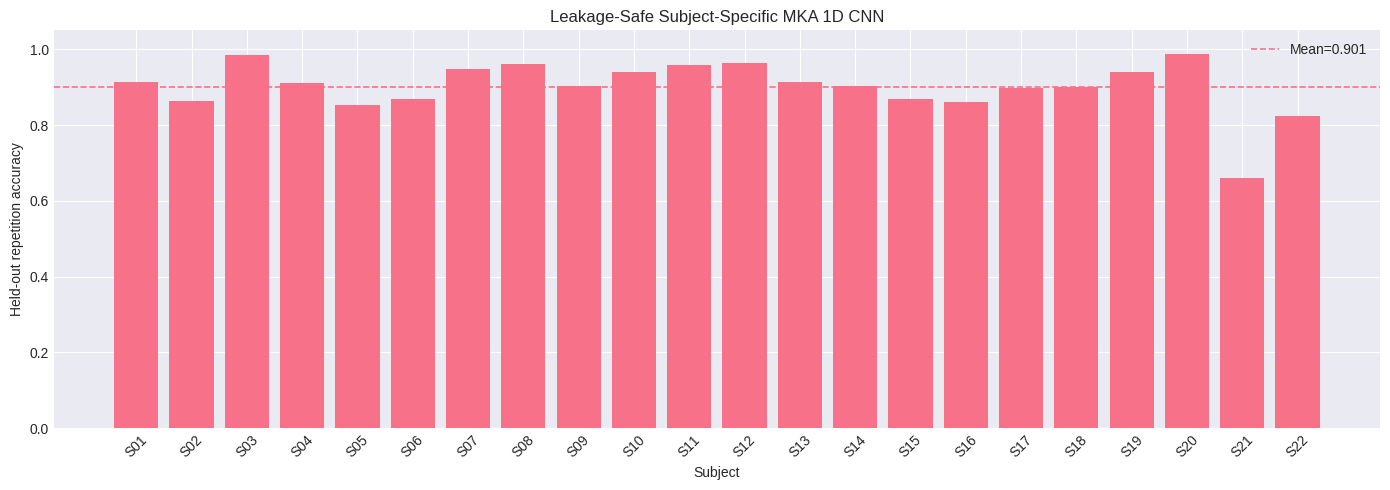

  Subject summary chart saved -> subject_specific_accuracy_summary.png

  FINAL SUBJECT-DEPENDENT WITHIN-SUBJECT CNN SUMMARY
 subject  accuracy  precision_w  recall_w     f1_w  roc_auc_w  best_epoch
       1  0.914286     0.921292  0.914286 0.910725   0.988795          40
       2  0.862595     0.890973  0.862595 0.854362   0.989041          29
       3  0.984211     0.987440  0.984211 0.983863   0.999944           6
       4  0.910811     0.924020  0.910811 0.909963   0.997022          11
       5  0.852998     0.881428  0.852998 0.849356   0.994084          21
       6  0.869932     0.888844  0.869932 0.865518   0.993667          13
       7  0.947368     0.959991  0.947368 0.945397   0.998802          36
       8  0.962302     0.963817  0.962302 0.962293   0.998617          18
       9  0.902256     0.922846  0.902256 0.902972   0.997548          10
      10  0.940945     0.946086  0.940945 0.939965   0.998432          18
      11  0.957801     0.965658  0.957801 0.957768   0.995597

In [15]:
def main():
    print('\n' + '=' * 70)
    print(
        '  SUBJECT-DEPENDENT WITHIN-SUBJECT MKA-CNN '
        '— DISK-SAFE STRICT EMG+ACC'
    )
    print('=' * 70)
    print(
        'Each subject is loaded, split, processed, trained and evaluated '
        'independently before moving to the next subject.'
    )
    print(
        'No raw-signal cache and no overlapping-window cache are saved.'
    )

    subject_loader = SubjectLoader()

    class_names = [
        f'G{gesture}'
        for gesture in range(
            Config.GESTURE_MIN,
            Config.GESTURE_MAX + 1,
        )
    ]

    all_metrics = []
    all_y_true = []
    all_y_proba = []
    all_assignments = {}
    all_provenance = {}

    expected_n_acc_ch = None
    n_channels = None

    for sid in Config.RUN_SUBJECTS:
        print('\n' + '-' * 70)
        print(
            f'  PREPARE SUBJECT S{sid:02d}: '
            'split repetitions before all signal transforms'
        )
        print('-' * 70)

        (
            data,
            assignment,
            provenance,
            subject_n_acc_ch,
        ) = subject_loader.build_subject_splits(
            sid,
            expected_n_acc_ch=expected_n_acc_ch,
        )

        if expected_n_acc_ch is None:
            expected_n_acc_ch = int(
                subject_n_acc_ch
            )
            n_channels = (
                Config.N_EMG_CH
                + expected_n_acc_ch
            )
            print(
                f'Global input width  : {n_channels} channels '
                f'({Config.N_EMG_CH} EMG + '
                f'{expected_n_acc_ch} ACC)'
            )
        elif int(subject_n_acc_ch) != int(expected_n_acc_ch):
            raise RuntimeError(
                f'S{sid:02d}: ACC channel count changed from '
                f'{expected_n_acc_ch} to {subject_n_acc_ch}.'
            )

        all_assignments[
            str(sid)
        ] = assignment
        all_provenance[
            str(sid)
        ] = provenance

        experiment = SubjectDependentCNNExperiment(
            sid=sid,
            data=data,
            n_channels=n_channels,
            n_classes=Config.N_CLASSES,
            class_names=class_names,
        )

        metrics, y_true, y_proba = (
            experiment.run()
        )

        all_metrics.append(metrics)
        all_y_true.append(y_true)
        all_y_proba.append(y_proba)

        serializable = {}
        for key, value in metrics.items():
            if isinstance(
                value,
                (np.floating, np.integer),
            ):
                serializable[key] = (
                    value.item()
                )
            else:
                serializable[key] = value

        with open(
            Config.RESULTS_DIR
            / (
                f'metrics_subject_dependent_'
                f'cnn_S{sid:02d}.json'
            ),
            'w',
        ) as file:
            json.dump(
                serializable,
                file,
                indent=2,
            )

        # Critical disk/RAM step: discard this subject before loading the next.
        del (
            data,
            experiment,
            y_true,
            y_proba,
        )
        gc.collect()

        if Config.DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    with open(
        Config.RESULTS_DIR
        / 'subject_dependent_repetition_assignments.json',
        'w',
    ) as file:
        json.dump(
            all_assignments,
            file,
            indent=2,
        )

    with open(
        Config.RESULTS_DIR
        / 'subject_dependent_repetition_provenance.json',
        'w',
    ) as file:
        json.dump(
            all_provenance,
            file,
            indent=2,
        )

    subject_df, aggregate = (
        aggregate_subject_results(
            all_metrics,
            all_y_true,
            all_y_proba,
        )
    )

    subject_df.to_csv(
        Config.RESULTS_DIR
        / 'subject_dependent_within_cnn_results.csv',
        index=False,
    )

    with open(
        Config.RESULTS_DIR
        / 'subject_dependent_within_cnn_aggregate.json',
        'w',
    ) as file:
        json.dump(
            aggregate,
            file,
            indent=2,
        )

    plot_subject_accuracy_summary(
        subject_df
    )

    print('\n' + '=' * 70)
    print(
        '  FINAL SUBJECT-DEPENDENT '
        'WITHIN-SUBJECT CNN SUMMARY'
    )
    print('=' * 70)

    print(
        subject_df[
            [
                'subject',
                'accuracy',
                'precision_w',
                'recall_w',
                'f1_w',
                'roc_auc_w',
                'best_epoch',
            ]
        ].to_string(index=False)
    )

    print(
        f'\nMean subject accuracy : '
        f'{aggregate["mean_subject_accuracy"]:.4f} ± '
        f'{aggregate["std_subject_accuracy"]:.4f}'
    )
    print(
        f'Mean subject F1       : '
        f'{aggregate["mean_subject_f1_w"]:.4f} ± '
        f'{aggregate["std_subject_f1_w"]:.4f}'
    )
    print(
        f'Pooled test accuracy  : '
        f'{aggregate["pooled_test_accuracy"]:.4f}'
    )

    print('\nCorrect interpretation:')
    print(
        '  SUBJECT-DEPENDENT / SUBJECT-SPECIFIC: '
        'each CNN is trained and tested on different repetitions '
        'from the SAME person.'
    )

    print('\nLeakage controls:')
    print('  ✓ one separate CNN trained from scratch for each subject')
    print('  ✓ complete repetitions assigned 4/1/1 before filtering/resampling/windowing')
    print('  ✓ train/val/test repetition-ID sets explicitly disjoint')
    print('  ✓ zero-phase EMG filtering applied only inside one assigned repetition')
    print('  ✓ ACC sliced from the same source file and resampled only inside that repetition')
    print('  ✓ overlapping windows remain entirely inside one repetition/split')
    print('  ✓ no random window-level train/test split')
    print('  ✓ normalization fitted on that subject’s training repetitions only')
    print('  ✓ validation used only for epoch selection')
    print('  ✓ fresh refit normalization/model use train+validation only')
    print('  ✓ test repetition untouched until final evaluation')
    print('  ✓ no persistent raw/window caches; one subject processed at a time')
    print('  ✓ temporary subject checkpoints deleted after evaluation')

    return (
        all_metrics,
        subject_df,
        aggregate,
        all_y_true,
        all_y_proba,
        all_assignments,
        all_provenance,
    )


if __name__ == '__main__':
    (
        all_metrics,
        per_subject_results,
        aggregate_results,
        all_y_true,
        all_y_proba,
        repetition_assignments,
        repetition_provenance,
    ) = main()